In [90]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,confusion_matrix,accuracy_score
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier

In [46]:
data=pd.read_csv(r"C:\Users\Sugavaneswara\Downloads\ecommerce_discount.csv")
data

,Units_Sold,Revenue,Discount_Percentage
0,8,5600,2.0
1,12,8400,2.5
2,15,10500,2.5
3,18,12600,3.0
4,20,14000,3.0
...,...,...,...
95,59,41300,5.9
96,69,48300,6.4
97,79,55300,7.3
98,89,62300,7.9


In [47]:
x=data[['Units_Sold','Revenue']]
x

,Units_Sold,Revenue
0,8,5600
1,12,8400
2,15,10500
3,18,12600
4,20,14000
...,...,...
95,59,41300
96,69,48300
97,79,55300
98,89,62300


In [48]:
y=data['Discount_Percentage']
y

0     2.0
1     2.5
2     2.5
3     3.0
4     3.0
     ... 
95    5.9
96    6.4
97    7.3
98    7.9
99    9.1
Name: Discount_Percentage, Length: 100, dtype: float64

In [49]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=40)

In [50]:
model=DecisionTreeRegressor(criterion='squared_error',random_state=40)
model.fit(x_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,40
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [51]:
y_pred=model.predict(x_test)

In [52]:
mse=mean_squared_error(y_test,y_pred)
print("Mean Squared Error:",mse)

r2=r2_score(y_test,y_pred)
print("Accuracy : ",r2 * 100)

Mean Squared Error: 0.024999999999999932
Accuracy :  99.65835793156226


In [53]:
unit_sold=int(input("Enter your units:"))
revenue=int(input("Enter your revenue:"))

x1=[[unit_sold,revenue]]
print(model.predict(x1))

Enter your units: 12
Enter your revenue: 70000


[8.5]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


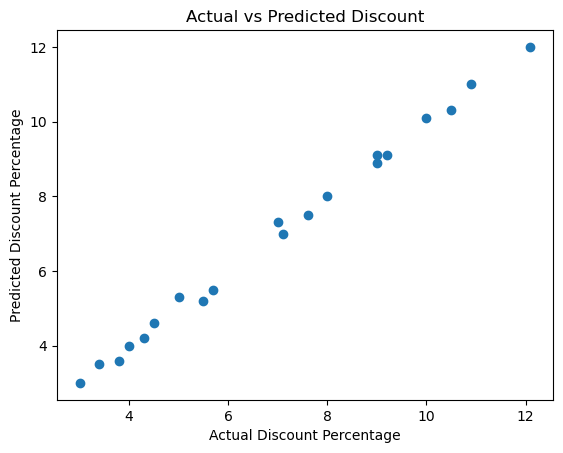

In [54]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Discount Percentage")
plt.ylabel("Predicted Discount Percentage")
plt.title("Actual vs Predicted Discount")
plt.show()

In [72]:
data = pd.read_csv(r"C:\Users\Sugavaneswara\Downloads\house_price.csv")
data

,Area_SqFt,Bedrooms,Bathrooms,House_Age,House_Price_Lakhs
0,1510,3,3,18,29.29
1,1944,2,2,29,20.26
2,1780,2,1,26,32.02
3,1745,3,3,19,40.80
4,2288,3,3,19,41.21
...,...,...,...,...,...
195,1786,3,3,4,38.89
196,2503,4,4,13,45.28
197,2170,2,2,11,34.92
198,3139,5,4,3,59.74


In [74]:
x = data[['Area_SqFt', 'Bedrooms', 'Bathrooms', 'House_Age']]
y = data['House_Price_Lakhs']
print(x)
print(y)

     Area_SqFt  Bedrooms  Bathrooms  House_Age
0         1510         3          3         18
1         1944         2          2         29
2         1780         2          1         26
3         1745         3          3         19
4         2288         3          3         19
..         ...       ...        ...        ...
195       1786         3          3          4
196       2503         4          4         13
197       2170         2          2         11
198       3139         5          4          3
199       1213         2          2          1

[200 rows x 4 columns]
0      29.29
1      20.26
2      32.02
3      40.80
4      41.21
       ...  
195    38.89
196    45.28
197    34.92
198    59.74
199    19.62
Name: House_Price_Lakhs, Length: 200, dtype: float64


In [75]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=40)

In [76]:
model = RandomForestRegressor(n_estimators=20)
model.fit(x_train, y_train)

,n_estimators,20
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [77]:
y_pred = model.predict(x_test)

In [78]:
r2 = r2_score(y_test, y_pred)
print("Accuracy:", r2 * 100)

Accuracy: 92.90029186121723


In [79]:
area = int(input("Enter house area in sq.ft: "))
bedrooms = int(input("Enter number of bedrooms: "))
bathrooms = int(input("Enter number of bathrooms: "))
age = int(input("Enter house age: "))

x1 = pd.DataFrame([[area, bedrooms, bathrooms, age]],columns=x.columns)

print("Predicted House Price (Lakhs):", model.predict(x1)[0])

Enter house area in sq.ft:  2100
Enter number of bedrooms:  2
Enter number of bathrooms:  2
Enter house age:  3


Predicted House Price (Lakhs): 35.691500000000005


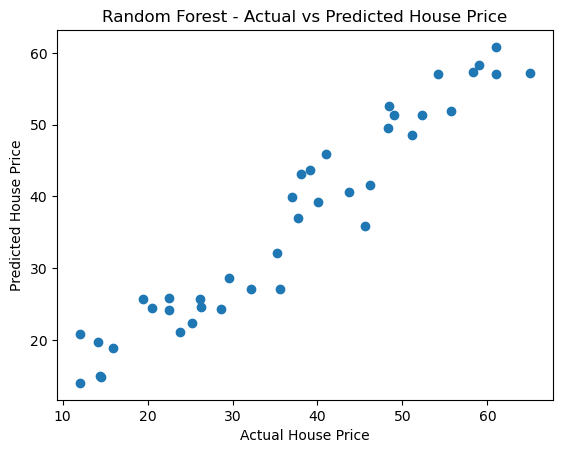

In [80]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Random Forest - Actual vs Predicted House Price")
plt.show()

In [81]:
data = pd.read_csv(r"C:\Users\Sugavaneswara\Downloads\house_price_classification.csv")
data

,Area_SqFt,Bedrooms,Bathrooms,House_Age,Price_Category
0,2917,3,2,18,Medium
1,2705,5,4,18,High
2,2863,3,2,1,Medium
3,1980,3,3,1,Medium
4,2513,4,3,5,Medium
...,...,...,...,...,...
95,2446,4,3,3,Medium
96,2803,5,4,25,Medium
97,2792,4,2,3,Medium
98,1996,4,3,22,Medium


In [82]:
x = data[['Area_SqFt', 'Bedrooms', 'Bathrooms', 'House_Age']]
y = data['Price_Category']

x

,Area_SqFt,Bedrooms,Bathrooms,House_Age
0,2917,3,2,18
1,2705,5,4,18
2,2863,3,2,1
3,1980,3,3,1
4,2513,4,3,5
...,...,...,...,...
95,2446,4,3,3
96,2803,5,4,25
97,2792,4,2,3
98,1996,4,3,22


In [83]:
y

0     Medium
1       High
2     Medium
3     Medium
4     Medium
       ...  
95    Medium
96    Medium
97    Medium
98    Medium
99    Medium
Name: Price_Category, Length: 100, dtype: object

In [84]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.20,random_state=42)

In [87]:
model = RandomForestClassifier(n_estimators=15)

In [88]:
model.fit(x_train, y_train)

,n_estimators,15
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [89]:
y_pred = model.predict(x_test)

In [92]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy*100)

Accuracy: 80.0


In [93]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 0  0  2]
 [ 0  6  2]
 [ 0  0 10]]


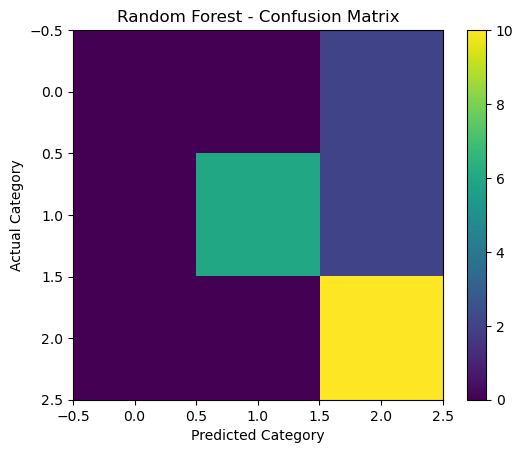

In [94]:
plt.imshow(cm)

plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.title("Random Forest - Confusion Matrix")

plt.colorbar()

plt.show()

In [95]:
area = int(input("Enter house area in sq.ft: "))
bedrooms = int(input("Enter number of bedrooms: "))
bathrooms = int(input("Enter number of bathrooms: "))
age = int(input("Enter house age: "))

x1 = [[area, bedrooms, bathrooms, age]]

prediction = model.predict(x1)

print("Predicted House Price Category:", prediction[0])

Enter house area in sq.ft:  1200
Enter number of bedrooms:  2
Enter number of bathrooms:  2
Enter house age:  5


Predicted House Price Category: Low


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
